In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
ticker = 'SPY'
data = yf.download(ticker, start='2022-01-01', end='2026-03-10')['Close']['SPY']

[*********************100%***********************]  1 of 1 completed


In [3]:
daily_returns = data.pct_change()
daily_returns = daily_returns.dropna()
sigma = daily_returns.std() * np.sqrt(252)

In [4]:
S0 = data.iloc[-1]  # Precio spot actual
r = 0.08            # Tasa libre de riesgo
T = 100 / 365       # Tiempo al vencimiento en años

num_simulations = 10000

In [5]:
Z = np.random.normal(0, 1, num_simulations)

In [6]:
St = S0 * np.exp((r - 0.5 * sigma ** 2) * T + sigma * np.sqrt(T) * Z)

In [7]:
K = 580

In [8]:
call = np.maximum(St - K, 0)
put = np.maximum(K - St, 0)

In [9]:
call_value = np.exp(-r * T) * np.mean(call)
put_value = np.exp(-r * T) * np.mean(put)

In [10]:
call_value

110.45771341400086

In [11]:
put_value

0.5915423695417612

### Parte 1 — Volatilidad
Modificar únicamente σ.

Probar con:

σ = 0.01
σ = 0.10
σ = 0.20
σ = 0.40
Graficar:

Distribución del precio Spot final en los 4 escenarios
Crear:

Crear una tabla con el valor de la call para cada escenario

Crear una tabla con el valor de la put para cada escenario

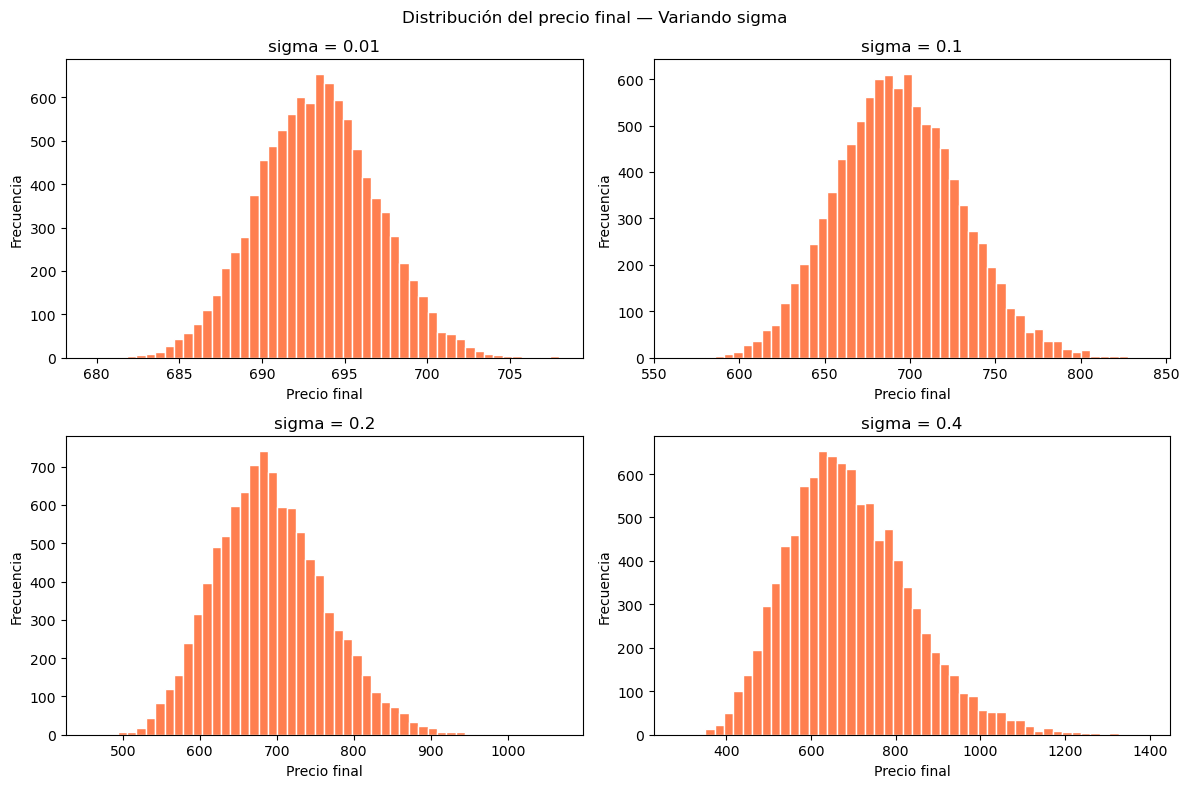

In [23]:
sigmas = [0.01, 0.10, 0.20, 0.40]

call_results_sigma = []
put_results_sigma = []

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, s in enumerate(sigmas):
    Z = np.random.normal(0, 1, num_simulations)
    St = S0 * np.exp((r - 0.5 * s**2) * T + s * np.sqrt(T) * Z)

    call = np.maximum(St - K, 0)
    put  = np.maximum(K - St, 0)

    call_value = np.exp(-r * T) * np.mean(call)
    put_value  = np.exp(-r * T) * np.mean(put)

    call_results_sigma.append(call_value)
    put_results_sigma.append(put_value)

    axes[i].hist(St, bins=50, color='coral', edgecolor='white')
    axes[i].set_title("sigma = " + str(s))
    axes[i].set_xlabel("Precio final")
    axes[i].set_ylabel("Frecuencia")

plt.suptitle("Distribución del precio final — Variando sigma")
plt.tight_layout()
plt.show()

In [20]:
# Tabla call
print("CALL values")
for i, s in enumerate(sigmas):
    print("sigma = " + str(s) + "  =>  Call = " + str(round(call_results_sigma[i], 4)))

# Tabla put
print("")
print("PUT values")
for i, s in enumerate(sigmas):
    print("sigma = " + str(s) + "  =>  Put = " + str(round(put_results_sigma[i], 4)))

CALL values
sigma = 0.01  =>  Call = 110.9069
sigma = 0.1  =>  Call = 111.123
sigma = 0.2  =>  Call = 111.0347
sigma = 0.4  =>  Call = 127.0545

PUT values
sigma = 0.01  =>  Put = 0.0
sigma = 0.1  =>  Put = 0.0023
sigma = 0.2  =>  Put = 1.1933
sigma = 0.4  =>  Put = 13.3418


### Preguntas

¿Qué sucede con la dispersión de las trayectorias? Conforme aumenta la volatilidad (sigma) aumenta notablemente la dispersión, se abren más posibilidades para el precio y en este caso, entre más volatilidad, la distribución se aleja de la normalidad. 

¿Cómo cambia la distribución de precios? El eje x se hace más grande y la distribución se sesga.

¿Aumenta o disminuye el valor de la opción conforme aumenta sigma? Aumenta.

## Actividad 2 — Tiempo al vencimiento
Modificar únicamente T.

Probar con:

T = 30 días
T = 100 días
T = 1 año
Graficar nuevamente:

1- Distribución final del precio Spot

Crear nuevamente

Crear una tabla con el valor de la call para cada escenario

Crear una tabla con el valor de la put para cada escenario


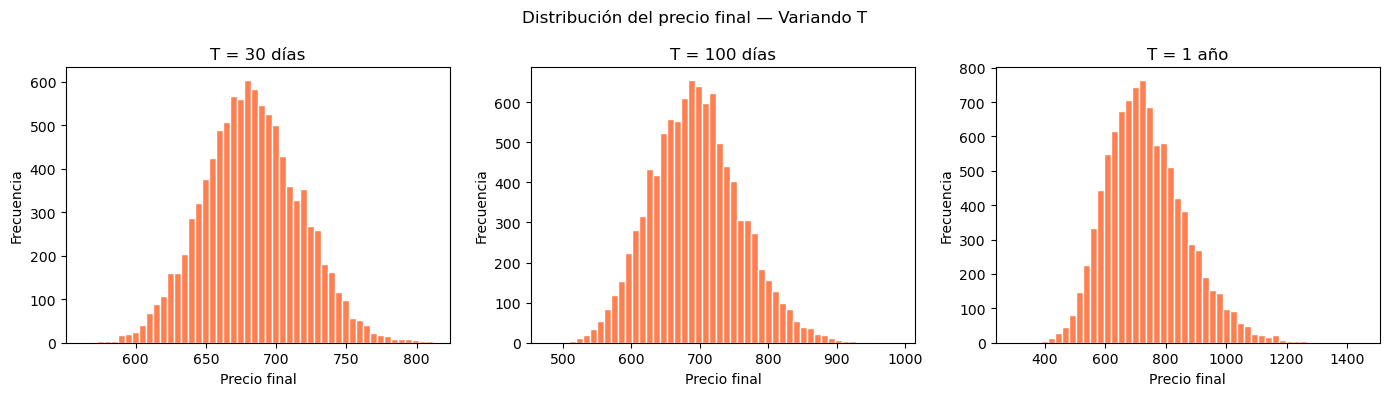

In [21]:
tiempos = [30/365, 100/365, 1]
etiquetas_T = ["30 días", "100 días", "1 año"]

call_results_T = []
put_results_T = []

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, t in enumerate(tiempos):
    Z = np.random.normal(0, 1, num_simulations)
    St = S0 * np.exp((r - 0.5 * sigma**2) * t + sigma * np.sqrt(t) * Z)

    call = np.maximum(St - K, 0)
    put  = np.maximum(K - St, 0)

    call_value = np.exp(-r * t) * np.mean(call)
    put_value  = np.exp(-r * t) * np.mean(put)

    call_results_T.append(call_value)
    put_results_T.append(put_value)

    axes[i].hist(St, bins=50, color='coral', edgecolor='white')
    axes[i].set_title("T = " + etiquetas_T[i])
    axes[i].set_xlabel("Precio final")
    axes[i].set_ylabel("Frecuencia")

plt.suptitle("Distribución del precio final — Variando T")
plt.tight_layout()
plt.show()

In [26]:

# Tabla call
print("CALL values")
for i, t in enumerate(etiquetas_T):
    print("T = " + t + "  =>  Call = " + str(round(call_results_T[i], 4)))

# Tabla put
print("")
print("PUT values")
for i, t in enumerate(etiquetas_T):
    print("T = " + t + "  =>  Put = " + str(round(put_results_T[i], 4)))

CALL values
T = 30 días  =>  Call = 102.0554
T = 100 días  =>  Call = 112.3384
T = 1 año  =>  Call = 147.7796

PUT values
T = 30 días  =>  Put = 0.0037
T = 100 días  =>  Put = 0.6244
T = 1 año  =>  Put = 4.1981


### Preguntas
**¿Cómo cambia la distribución final del precio al aumentar T?** Muy similar al cambio con sigma, aumenta el eje de las x y también se sesga más a la izquierda. 

**¿Aumenta o disminuye el valor de la opción conforme aumenta tiempo?** Aumenta el valor de la opción conforme aumenta el tiempo y tiene mucho sentido, al ser más amplio el horizonte de tiempo, hay más incertidumbre de lo que pueda pasar, entonces el valor de tener la opción de comprar o vender, aumenta.

## Actividad 3 — Precio de ejercicio

Modificar únicamente K.

Probar con:

K = S0 * 0.70
K = S0 * 0.90
K = S0
K = S0 * 1.10
K = S0 * 1.30
Crear:

Crear una tabla con el valor de la call para cada escenario

Crear una tabla con el valor de la put para cada escenario

In [37]:
strikes = [S0 * 0.70, S0 * 0.90, S0, S0 * 1.10, S0 * 1.30]
etiquetas_K = ["S0 * 0.70", "S0 * 0.90", "S0", "S0 * 1.10", "S0 * 1.30"]

call_results_K = []
put_results_K = []

Z = np.random.normal(0, 1, num_simulations)
St = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

for i, k in enumerate(strikes):
    call = np.maximum(St - k, 0)
    put  = np.maximum(k - St, 0)

    call_value = np.exp(-r * T) * np.mean(call)
    put_value  = np.exp(-r * T) * np.mean(put)

    call_results_K.append(call_value)
    put_results_K.append(put_value)

# Tabla call
print("CALL values")
for i, k in enumerate(etiquetas_K):
    print("K = " + k + "  =>  Call = " + str(round(call_results_K[i], 4)))

# Tabla put
print("")
print("PUT values")
for i, k in enumerate(etiquetas_K):
    print("K = " + k + "  =>  Put = " + str(round(put_results_K[i], 4)))


CALL values
K = S0 * 0.70  =>  Call = 214.8591
K = S0 * 0.90  =>  Call = 84.4237
K = S0  =>  Call = 33.8981
K = S0 * 1.10  =>  Call = 8.4324
K = S0 * 1.30  =>  Call = 0.125

PUT values
K = S0 * 0.70  =>  Put = 0.0
K = S0 * 0.90  =>  Put = 2.2777
K = S0  =>  Put = 18.1087
K = S0 * 1.10  =>  Put = 58.9995
K = S0 * 1.30  =>  Put = 183.4052


In [31]:
# Tabla call
print("CALL values")
for i, k in enumerate(etiquetas_K):
    print("K = " + k + "  =>  Call = " + str(round(call_results_K[i], 4)))

# Tabla put
print("")
print("PUT values")
for i, k in enumerate(etiquetas_K):
    print("K = " + k + "  =>  Put = " + str(round(put_results_K[i], 4)))

CALL values
K = S0 * 0.70  =>  Call = 213.3165
K = S0 * 0.90  =>  Call = 83.0589
K = S0  =>  Call = 33.0139
K = S0 * 1.10  =>  Call = 8.1067
K = S0 * 1.30  =>  Call = 0.1415

PUT values
K = S0 * 0.70  =>  Put = 0.0
K = S0 * 0.90  =>  Put = 2.4555
K = S0  =>  Put = 18.7671
K = S0 * 1.10  =>  Put = 60.2164
K = S0 * 1.30  =>  Put = 184.9643


### Preguntas

**¿Aumenta o disminuye el valor de la opción conforme aumenta K?**  Los call values disminuten y los put values aumentan. 

**¿Qué ocurre cuando el strike es relativamente muy alto? ¿Cuando es muy bajo?** Se aleja muchísimo del K = S0.

## Actividad 4 — Tasa libre de riesgo

Modificar únicamente r.

Probar con:

r = 0.01
r = 0.05
r = 0.10
Graficar:
1- Distribución final del precio Spot

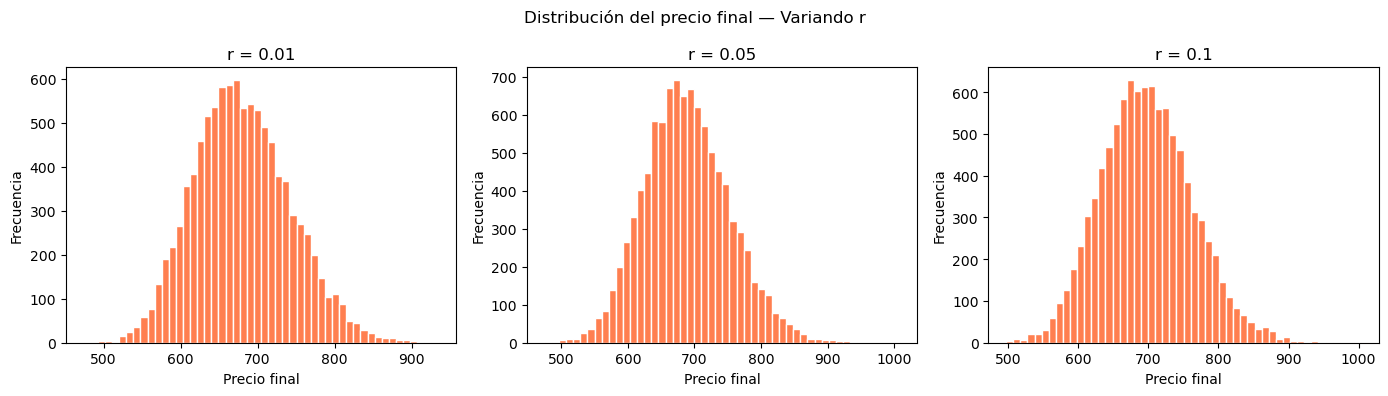

In [40]:

tasas = [0.01, 0.05, 0.10]

call_results_r = []
put_results_r = []

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, ri in enumerate(tasas):
    Z = np.random.normal(0, 1, num_simulations)
    St = S0 * np.exp((ri - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    call = np.maximum(St - K, 0)
    put  = np.maximum(K - St, 0)

    call_value = np.exp(-ri * T) * np.mean(call)
    put_value  = np.exp(-ri * T) * np.mean(put)

    call_results_r.append(call_value)
    put_results_r.append(put_value)

    axes[i].hist(St, bins=50, color='coral', edgecolor='white')
    axes[i].set_title("r = " + str(ri))
    axes[i].set_xlabel("Precio final")
    axes[i].set_ylabel("Frecuencia")

plt.suptitle("Distribución del precio final — Variando r")
plt.tight_layout()
plt.show()


In [39]:
# Tabla call
print("CALL values")
for i, ri in enumerate(tasas):
    print("r = " + str(ri) + "  =>  Call = " + str(round(call_results_r[i], 4)))

# Tabla put
print("")
print("PUT values")
for i, ri in enumerate(tasas):
    print("r = " + str(ri) + "  =>  Put = " + str(round(put_results_r[i], 4)))

CALL values
r = 0.01  =>  Call = 100.7462
r = 0.05  =>  Call = 107.389
r = 0.1  =>  Call = 114.0023

PUT values
r = 0.01  =>  Put = 1.0846
r = 0.05  =>  Put = 0.7781
r = 0.1  =>  Put = 0.5794


### Preguntas

**¿Cómo cambia el crecimiento esperado del precio del activo?**  No exageradamente, no afecta taaanto y en las Call conforme aumenta la tasa, aumenta el valor, lo contrario con la put. 

**¿Qué sucede con el valor de la call cuando aumenta la tasa libre de riesgo?** Aumenta.

**¿Qué sucede con el valor de la put cuando aumenta la tasa libre de riesgo?** Disminuye.